<a href="https://colab.research.google.com/github/Tanvi6696/tomatoml/blob/main/tomatoml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [4]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print(os.listdir('/content/dataset'))

['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)']


In [5]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)
    if root.count(os.sep) > 4:
        dirs[:] = []

/content/dataset
/content/dataset/New Plant Diseases Dataset(Augmented)
/content/dataset/New Plant Diseases Dataset(Augmented)/valid
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Bacterial_spot
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Leaf_Mold
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Target_Spot
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Spider_mites Two-spotted_spider_mite
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___healthy
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Septoria_leaf_spot
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Early_blight
/content/dataset/New Plant Diseases Dataset(Augmented)/valid/Tomato___Tomato_mosa

In [6]:
import os

BASE_PATH = "/content/dataset"

for root, dirs, files in os.walk(BASE_PATH):
    if os.path.basename(root) == "train":
        TRAIN_DIR = root

    if os.path.basename(root) == "valid":
        VALID_DIR = root

print("Train:", TRAIN_DIR)
print("Valid:", VALID_DIR)

Train: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
Valid: /content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


In [7]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Number of classes:", len(classes))

for i, cls in enumerate(classes):
    print(i, cls)

Number of classes: 10
0 Tomato___Bacterial_spot
1 Tomato___Early_blight
2 Tomato___Late_blight
3 Tomato___Leaf_Mold
4 Tomato___Septoria_leaf_spot
5 Tomato___Spider_mites Two-spotted_spider_mite
6 Tomato___Target_Spot
7 Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 Tomato___Tomato_mosaic_virus
9 Tomato___healthy


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

Found 18345 files belonging to 10 classes.
Found 4585 files belonging to 10 classes.


In [9]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of classes: 10


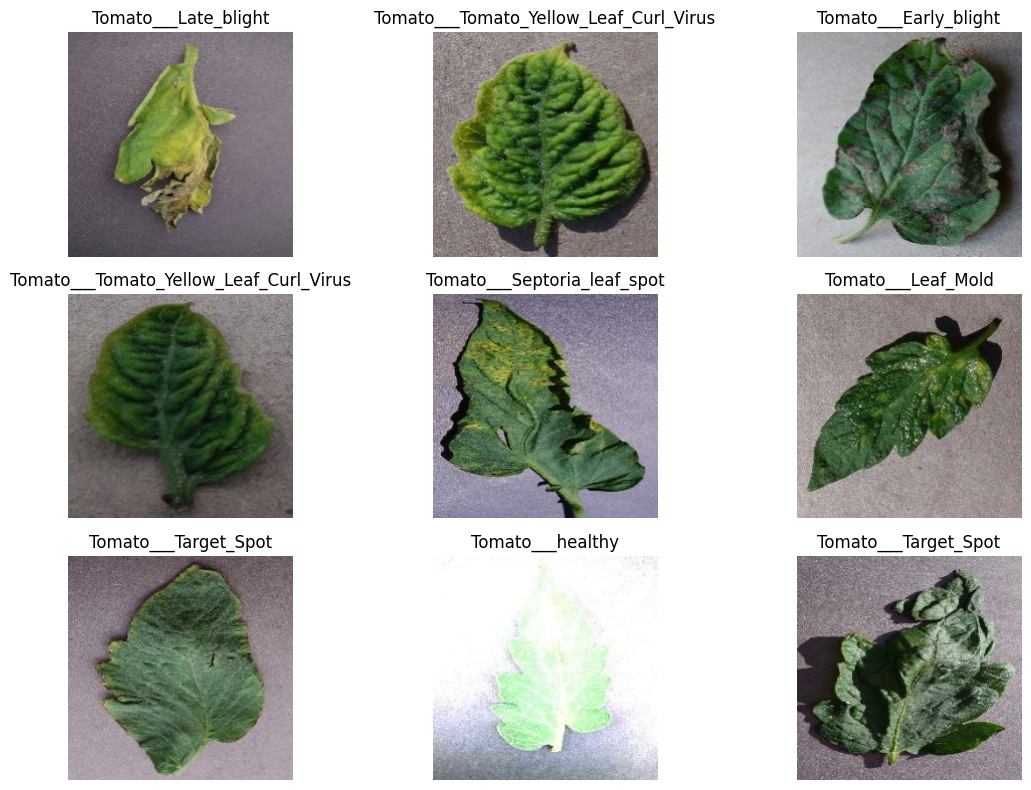

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1)
])

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

num_classes = len(class_names)

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation='softmax'
)(x)

model = models.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_tomato_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.7213 - loss: 0.9291 - val_accuracy: 0.8098 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 2/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 56s 98ms/step - accuracy: 0.8446 - loss: 0.5150 - val_accuracy: 0.8526 - val_loss: 0.4752 - learning_rate: 0.0010
Epoch 3/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 57s 100ms/step - accuracy: 0.8647 - loss: 0.4335 - val_accuracy: 0.8772 - val_loss: 0.3968 - learning_rate: 0.0010
Epoch 4/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 57s 99ms/step - accuracy: 0.8758 - loss: 0.3885 - val_accuracy: 0.8853 - val_loss: 0.3680 - learning_rate: 0.0010
Epoch 5/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 67s 116ms/step - accuracy: 0.8849 - loss: 0.3586 - val_accuracy: 0.8912 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 6/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 57s 99ms/step - accuracy: 0.8908 - loss: 0.3357 - val_accuracy: 0.8949 - val_loss: 0.3291 - learning_rate: 0.0010
Epoch 7/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.8951

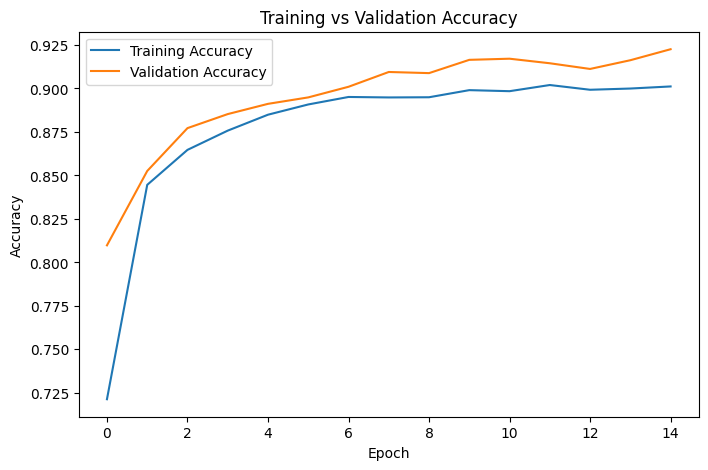

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

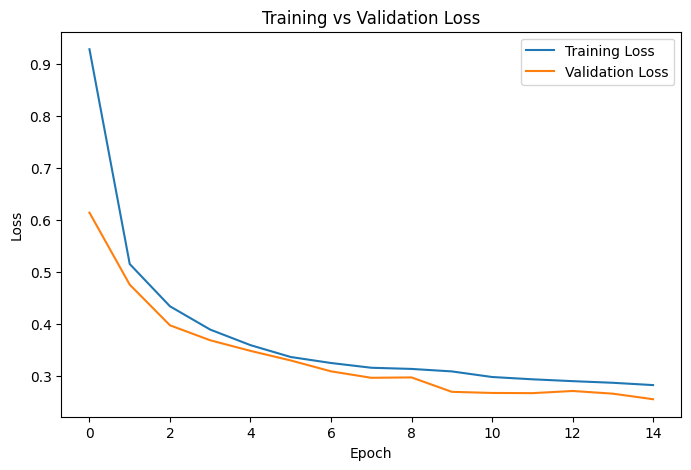

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [19]:
loss, accuracy = model.evaluate(valid_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9226 - loss: 0.2543
Validation Loss: 0.2543472349643707
Validation Accuracy: 0.9225736260414124


In [20]:
import numpy as np

y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.97      0.94      0.96       425
                        Tomato___Early_blight       0.95      0.82      0.88       480
                         Tomato___Late_blight       0.94      0.91      0.92       463
                           Tomato___Leaf_Mold       0.94      0.94      0.94       470
                  Tomato___Septoria_leaf_spot       0.89      0.90      0.89       436
Tomato___Spider_mites Two-spotted_spider_mite       0.92      0.90      0.91       435
                         Tomato___Target_Spot       0.78      0.93      0.85       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.95      0.97       490
                 Tomato___Tomato_mosaic_virus       1.00      0.96      0.98       448
                             Tomato___healthy       0.89      0.99      0.94       481

                                     accu

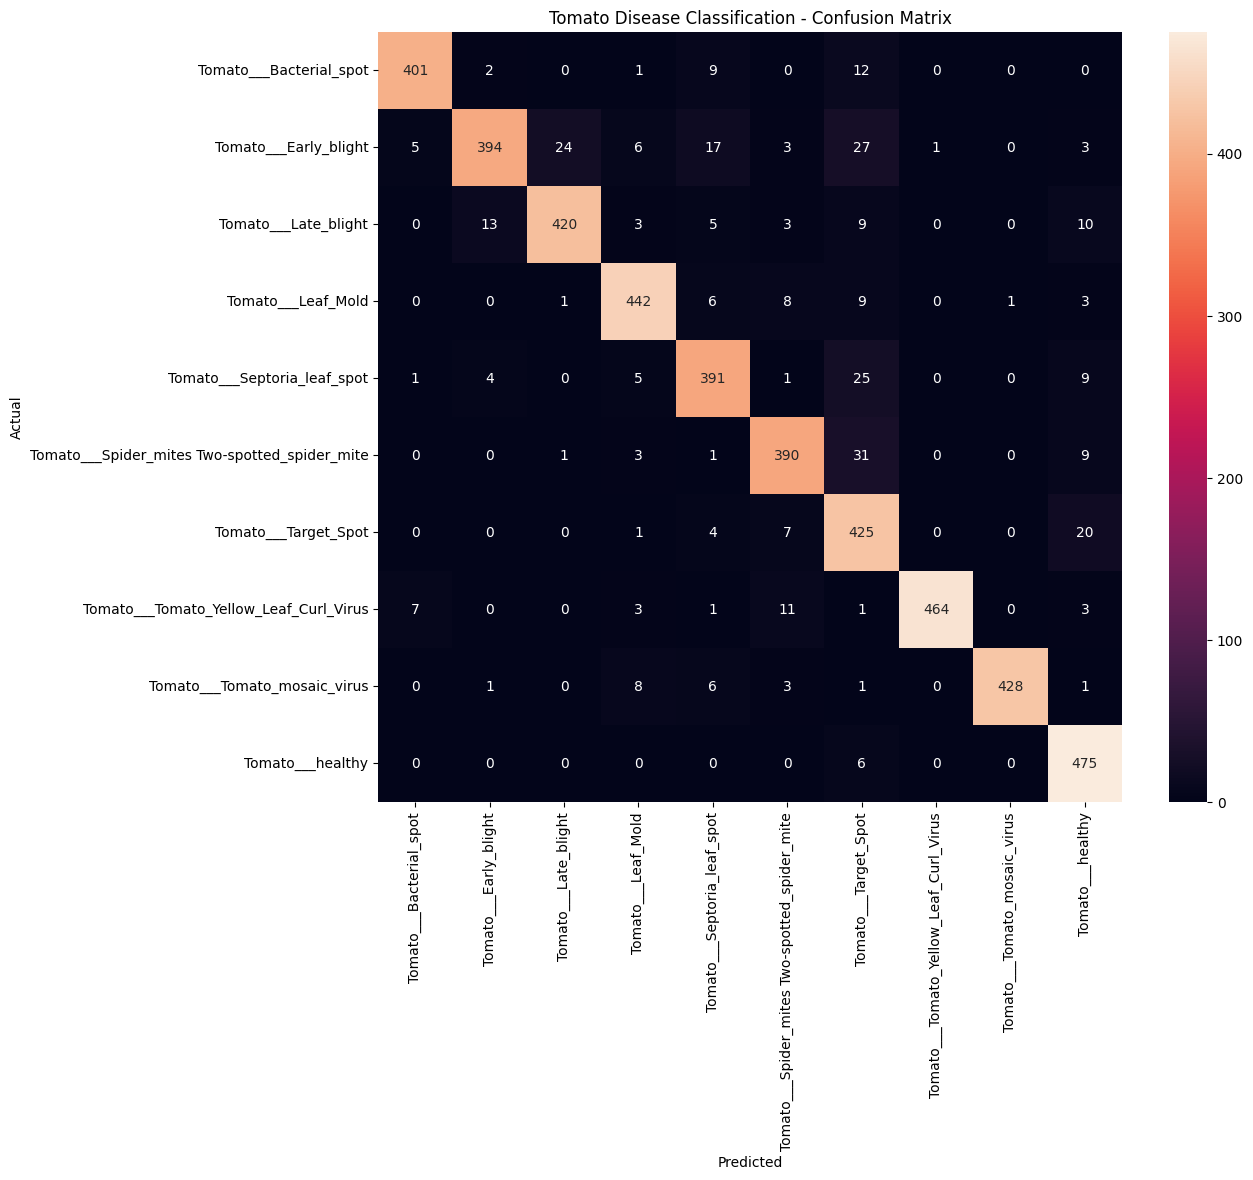

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tomato Disease Classification - Confusion Matrix")
plt.show()

In [24]:
from google.colab import files

uploaded_test = files.upload()

Saving Screenshot 2026-09-23 130143.png to Screenshot 2026-09-23 130143.png


In [25]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = list(uploaded_test.keys())[0]

img = load_img(
    image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
Predicted Disease: Tomato___Late_blight
Confidence: 89.44 %


In [26]:
# Find convolutional layers inside EfficientNet
base_model = model.get_layer("efficientnetb0")

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name, layer.output.shape)


stem_conv (None, 112, 112, 32)
block1a_se_reduce (None, 1, 1, 8)
block1a_se_expand (None, 1, 1, 32)
block1a_project_conv (None, 112, 112, 16)
block2a_expand_conv (None, 112, 112, 96)
block2a_se_reduce (None, 1, 1, 4)
block2a_se_expand (None, 1, 1, 96)
block2a_project_conv (None, 56, 56, 24)
block2b_expand_conv (None, 56, 56, 144)
block2b_se_reduce (None, 1, 1, 6)
block2b_se_expand (None, 1, 1, 144)
block2b_project_conv (None, 56, 56, 24)
block3a_expand_conv (None, 56, 56, 144)
block3a_se_reduce (None, 1, 1, 6)
block3a_se_expand (None, 1, 1, 144)
block3a_project_conv (None, 28, 28, 40)
block3b_expand_conv (None, 28, 28, 240)
block3b_se_reduce (None, 1, 1, 10)
block3b_se_expand (None, 1, 1, 240)
block3b_project_conv (None, 28, 28, 40)
block4a_expand_conv (None, 28, 28, 240)
block4a_se_reduce (None, 1, 1, 10)
block4a_se_expand (None, 1, 1, 240)
block4a_project_conv (None, 14, 14, 80)
block4b_expand_conv (None, 14, 14, 480)
block4b_se_reduce (None, 1, 1, 20)
block4b_se_expand (None, 1, 1, 

In [27]:
last_conv_layer = base_model.get_layer("top_conv")

In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer, pred_index=None):

    # Create model that returns:
    # 1. feature maps from convolutional layer
    # 2. final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradient of predicted class with respect to feature maps
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients across width and height
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps using gradients
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU: keep only positive influence
    heatmap = tf.maximum(heatmap, 0)

    # Normalize between 0 and 1
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

In [29]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print(image_path)

Saving Screenshot 2026-09-23 130143.png to Screenshot 2026-09-23 130143 (1).png
Screenshot 2026-09-23 130143 (1).png


In [30]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 224, 224, 3)


In [31]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_class_index]

confidence = predictions[0][predicted_class_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Disease: Tomato___Late_blight
Confidence: 89.44 %


In [32]:
last_conv_layer = base_model.get_layer("top_conv")

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer,
    pred_index=predicted_class_index
)

print(heatmap.shape)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_238']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m137684870349360\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[34., 36., 42.],\n         [34., 36., 42.],\n         [34., 36., 42.],\n         ...,\n         [34., 36., 42.],\n         [34., 36., 42.],\n         [34., 36., 42.]],\n\n        [[44., 46., 53.],\n         [44., 46., 53.],\n         [44., 46., 53.],\n         ...,\n         [44., 46., 53.],\n         [44., 46., 53.],\n         [44., 46., 53.]],\n\n        [[44., 46., 53.],\n         [44., 46., 53.],\n         [44., 46., 53.],\n         ...,\n         [44., 46., 53.],\n         [44., 46., 53.],\n         [44., 46., 53.]],\n\n        ...,\n\n        [[34., 36., 42.],\n         [34., 36., 42.],\n         [34., 36., 42.],\n         ...,\n         [34., 36., 42.],\n         [34., 36., 42.],\n         [34., 36., 42.]],\n\n        [[34., 36., 42.],\n         [34., 36., 42.],\n         [34., 36., 42.],\n         ...,\n         [34.,

In [33]:
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

None


In [34]:
import tensorflow as tf
import numpy as np


def make_gradcam_heatmap(img_array, model, base_model, pred_index=None):

    # Get layers from outer model
    augmentation_layer = model.get_layer(
        model.layers[1].name
    )

    pooling_layer = model.get_layer(
        "global_average_pooling2d"
    )

    dropout_layer = model.get_layer(
        "dropout"
    )

    classifier_layer = model.get_layer(
        "dense"
    )

    # Internal EfficientNet Grad-CAM model
    grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer("top_conv").output,
            base_model.output
        ]
    )

    # Apply the same augmentation used during training
    augmented_image = augmentation_layer(
        img_array,
        training=False
    )

    with tf.GradientTape() as tape:

        # EfficientNet
        conv_outputs, features = grad_model(
            augmented_image,
            training=False
        )

        # Classification head
        x = pooling_layer(features)
        x = dropout_layer(x, training=False)
        predictions = classifier_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradient
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [35]:
for layer in model.layers:
    print(layer.name)

input_layer_1
sequential
efficientnetb0
global_average_pooling2d
dropout
dense


In [36]:
base_model = model.get_layer("efficientnetb0")

In [37]:
last_conv_layer = base_model.get_layer("top_conv")

print(last_conv_layer)

<Conv2D name=top_conv, built=True>


In [38]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_class_index]

confidence = predictions[0][predicted_class_index] * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction: Tomato___Late_blight
Confidence: 89.44 %


In [39]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    base_model,
    pred_index=predicted_class_index
)

print("Heatmap shape:", heatmap.shape)

Heatmap shape: (7, 7)


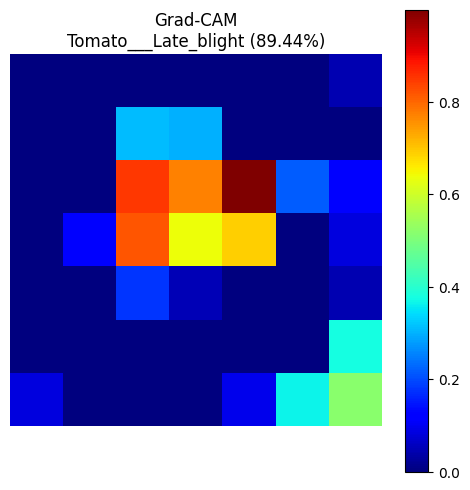

In [40]:
plt.figure(figsize=(6, 6))

plt.imshow(heatmap, cmap="jet")

plt.colorbar()

plt.title(
    f"Grad-CAM\n"
    f"{predicted_class} ({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

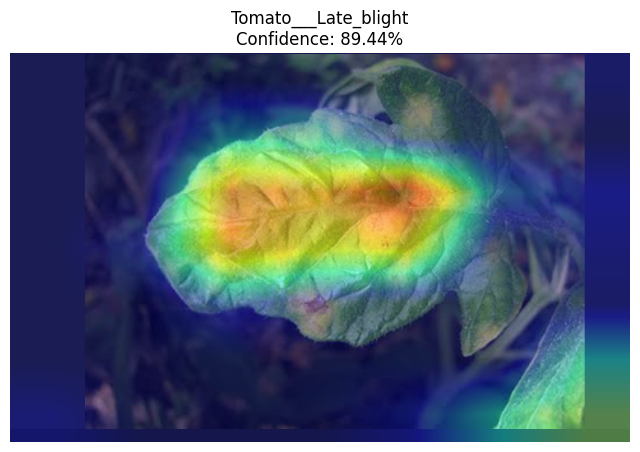

In [41]:
import cv2

# Read original image
original = cv2.imread(image_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

# Convert to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    f"{predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [42]:
import os

print(os.listdir('/content'))

['.config', 'https:', 'archive (4).zip', 'best_tomato_model.keras', 'dataset', 'Screenshot 2026-09-23 130143.png', 'Screenshot 2026-09-23 130143 (1).png', 'sample_data']


In [43]:
print(os.listdir('/content'))

['.config', 'https:', 'archive (4).zip', 'best_tomato_model.keras', 'dataset', 'Screenshot 2026-09-23 130143.png', 'Screenshot 2026-09-23 130143 (1).png', 'sample_data']


In [44]:
from tensorflow.keras.models import load_model

model = load_model('/content/best_tomato_model.keras')

print("Model loaded successfully!")

Model loaded successfully!


In [45]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_1 InputLayer
1 sequential Sequential
2 efficientnetb0 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dropout Dropout
5 dense Dense


In [46]:
base_model = model.get_layer("efficientnetb0")

print(base_model.name)

efficientnetb0


In [47]:
for layer in base_model.layers:
    if len(layer.output.shape) == 4:
        print(layer.name, layer.output.shape)

input_layer (None, 224, 224, 3)
rescaling (None, 224, 224, 3)
normalization (None, 224, 224, 3)
rescaling_1 (None, 224, 224, 3)
stem_conv_pad (None, 225, 225, 3)
stem_conv (None, 112, 112, 32)
stem_bn (None, 112, 112, 32)
stem_activation (None, 112, 112, 32)
block1a_dwconv (None, 112, 112, 32)
block1a_bn (None, 112, 112, 32)
block1a_activation (None, 112, 112, 32)
block1a_se_reshape (None, 1, 1, 32)
block1a_se_reduce (None, 1, 1, 8)
block1a_se_expand (None, 1, 1, 32)
block1a_se_excite (None, 112, 112, 32)
block1a_project_conv (None, 112, 112, 16)
block1a_project_bn (None, 112, 112, 16)
block2a_expand_conv (None, 112, 112, 96)
block2a_expand_bn (None, 112, 112, 96)
block2a_expand_activation (None, 112, 112, 96)
block2a_dwconv_pad (None, 113, 113, 96)
block2a_dwconv (None, 56, 56, 96)
block2a_bn (None, 56, 56, 96)
block2a_activation (None, 56, 56, 96)
block2a_se_reshape (None, 1, 1, 96)
block2a_se_reduce (None, 1, 1, 4)
block2a_se_expand (None, 1, 1, 96)
block2a_se_excite (None, 56, 56, 

In [48]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, pred_index=None):

    # Outer model layers
    augmentation = model.get_layer("sequential")
    base_model = model.get_layer("efficientnetb0")
    pooling = model.get_layer("global_average_pooling2d")
    dropout = model.get_layer("dropout")
    classifier = model.get_layer("dense")

    # EfficientNet Grad-CAM model
    grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer("top_conv").output,
            base_model.output
        ]
    )

    # Apply augmentation
    x = augmentation(
        img_array,
        training=False
    )

    with tf.GradientTape() as tape:

        # EfficientNet
        conv_outputs, features = grad_model(
            x,
            training=False
        )

        # Classification head
        x = pooling(features)
        x = dropout(x, training=False)
        predictions = classifier(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Keep positive influence
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [49]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, pred_index=None):

    # Outer model layers
    augmentation = model.get_layer("sequential")
    base_model = model.get_layer("efficientnetb0")
    pooling = model.get_layer("global_average_pooling2d")
    dropout = model.get_layer("dropout")
    classifier = model.get_layer("dense")

    # EfficientNet Grad-CAM model
    grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer("top_conv").output,
            base_model.output
        ]
    )

    # Apply augmentation
    x = augmentation(
        img_array,
        training=False
    )

    with tf.GradientTape() as tape:

        # EfficientNet
        conv_outputs, features = grad_model(
            x,
            training=False
        )

        # Classification head
        x = pooling(features)
        x = dropout(x, training=False)
        predictions = classifier(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Keep positive influence
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [50]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_class_index]

confidence = predictions[0][predicted_class_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Disease: Tomato___Late_blight
Confidence: 89.44 %


In [51]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    pred_index=predicted_class_index
)

print("Heatmap shape:", heatmap.shape)

Heatmap shape: (7, 7)


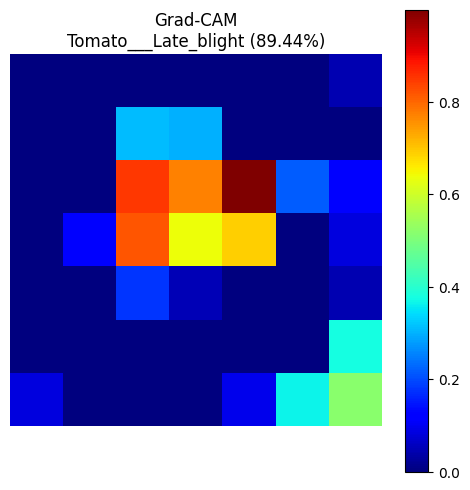

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title(
    f"Grad-CAM\n"
    f"{predicted_class} ({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

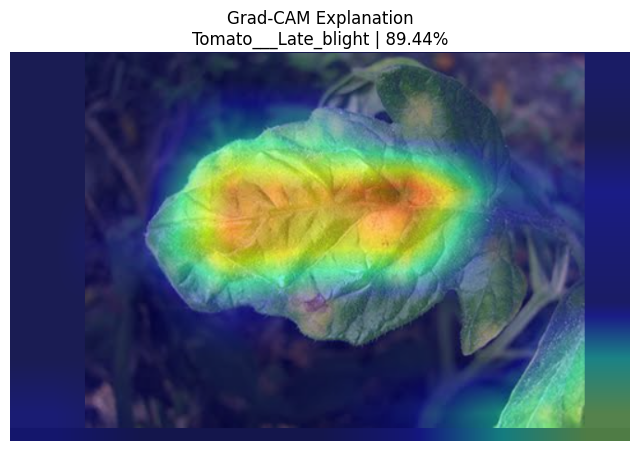

In [53]:
import cv2

# Load original image
original = cv2.imread(image_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# Resize heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    f"Grad-CAM Explanation\n"
    f"{predicted_class} | {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [54]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving Screenshot 2026-09-23 140636.png to Screenshot 2026-09-23 140636.png


In [55]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img = load_img(
    image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array.astype("float32")

In [56]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_index]
confidence = predictions[0][predicted_class_index] * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction: Tomato___Early_blight
Confidence: 98.46 %


In [57]:
top_3_indices = np.argsort(predictions[0])[-3:][::-1]

print("Top 3 Predictions:\n")

for i in top_3_indices:
    print(
        f"{class_names[i]}: "
        f"{predictions[0][i] * 100:.2f}%"
    )

Top 3 Predictions:

Tomato___Early_blight: 98.46%
Tomato___Late_blight: 1.50%
Tomato___Septoria_leaf_spot: 0.04%


In [58]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    pred_index=predicted_class_index
)

In [59]:
model.save("/content/tomato_disease_efficientnet.keras")

print("Model saved successfully!")

Model saved successfully!


In [60]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names:")
print(class_names)

Class names:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [61]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-23 143229.png to Screenshot 2026-09-23 143229.png


In [62]:
import os

uploaded_files = list(uploaded.keys())

print("Number of images:", len(uploaded_files))
print(uploaded_files)

Number of images: 1
['Screenshot 2026-09-23 143229.png']


In [63]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import load_img, img_to_array

results = []

for image_path in uploaded_files:

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype("float32")

    predictions = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    results.append({
        "Image": image_path,
        "Predicted Disease": predicted_class,
        "Confidence (%)": round(confidence, 2)
    })

results_df = pd.DataFrame(results)

results_df

,Image,Predicted Disease,Confidence (%)
0,Screenshot 2026-09-23 143229.png,Tomato___Septoria_leaf_spot,65.190002


In [64]:
top3_results = []

for image_path in uploaded_files:

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype("float32")

    predictions = model.predict(img_array, verbose=0)[0]

    top3_indices = np.argsort(predictions)[-3:][::-1]

    row = {
        "Image": image_path
    }

    for rank, index in enumerate(top3_indices, start=1):
        row[f"Top {rank}"] = class_names[index]
        row[f"Confidence {rank} (%)"] = round(predictions[index] * 100, 2)

    top3_results.append(row)

top3_df = pd.DataFrame(top3_results)

top3_df

,Image,Top 1,Confidence 1 (%),Top 2,Confidence 2 (%),Top 3,Confidence 3 (%)
0,Screenshot 2026-09-23 143229.png,Tomato___Septoria_leaf_spot,65.190002,Tomato___Early_blight,25.290001,Tomato___Bacterial_spot,8.65


In [65]:
results_df.sort_values(
    by="Confidence (%)"
).head(10)

,Image,Predicted Disease,Confidence (%)
0,Screenshot 2026-09-23 143229.png,Tomato___Septoria_leaf_spot,65.190002


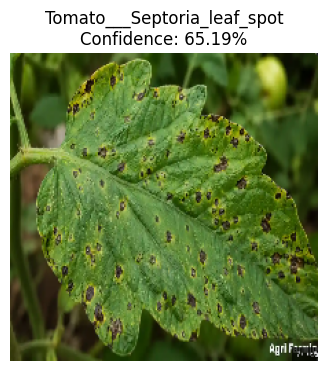

In [66]:
import matplotlib.pyplot as plt

for image_path in uploaded_files:

    img = load_img(image_path, target_size=(224, 224))

    predictions = model.predict(
        np.expand_dims(img_to_array(img), axis=0).astype("float32"),
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"{predicted_class}\nConfidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

In [67]:
image_path = uploaded_files[0]

In [68]:
img = load_img(image_path, target_size=(224, 224))

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0).astype("float32")

In [69]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_index]
confidence = predictions[0][predicted_class_index] * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Tomato___Septoria_leaf_spot
Confidence: 65.19 %


In [70]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    pred_index=predicted_class_index
)

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

heatmap_resized = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

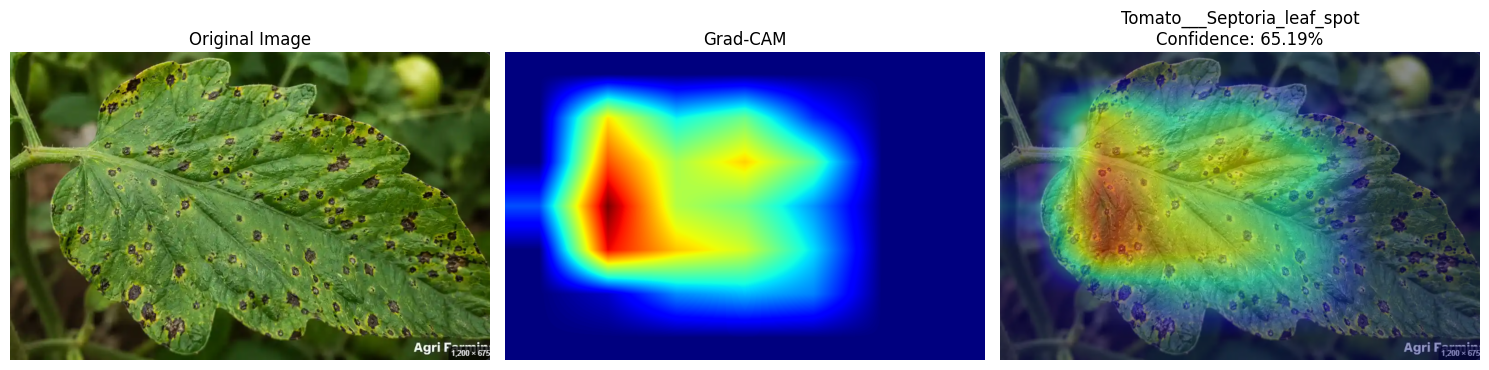

In [72]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [73]:
actual_labels = [
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Healthy",
    # ...
]

In [74]:
uploaded_files

['Screenshot 2026-09-23 143229.png']

In [75]:
from sklearn.metrics import accuracy_score

predicted_labels = results_df["Predicted Disease"].tolist()

accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

print("Unseen Test Accuracy:", round(accuracy * 100, 2), "%")

ValueError: Found input variables with inconsistent numbers of samples: [3, 1]

In [76]:
print("Uploaded files:", len(uploaded_files))
print("Actual labels:", len(actual_labels))
print("Predicted labels:", len(predicted_labels))

print("\nFiles:")
print(uploaded_files)

print("\nActual:")
print(actual_labels)

print("\nPredicted:")
print(predicted_labels)

Uploaded files: 1
Actual labels: 3
Predicted labels: 1

Files:
['Screenshot 2026-09-23 143229.png']

Actual:
['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Healthy']

Predicted:
['Tomato___Septoria_leaf_spot']


In [77]:
print("Image:", uploaded_files[0])
print("Predicted:", predicted_labels[0])

Image: Screenshot 2026-09-23 143229.png
Predicted: Tomato___Septoria_leaf_spot


In [78]:
from google.colab import files

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

print("Number of images uploaded:", len(uploaded_files))
print(uploaded_files)

Saving Screenshot 2026-09-23 130143.png to Screenshot 2026-09-23 130143 (2).png
Saving Screenshot 2026-09-23 140636.png to Screenshot 2026-09-23 140636 (1).png
Saving Screenshot 2026-09-23 143229.png to Screenshot 2026-09-23 143229 (1).png
Saving Screenshot 2026-09-23 144158.png to Screenshot 2026-09-23 144158.png
Saving Screenshot 2026-09-23 144349.png to Screenshot 2026-09-23 144349.png
Number of images uploaded: 5
['Screenshot 2026-09-23 130143 (2).png', 'Screenshot 2026-09-23 140636 (1).png', 'Screenshot 2026-09-23 143229 (1).png', 'Screenshot 2026-09-23 144158.png', 'Screenshot 2026-09-23 144349.png']


In [79]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import load_img, img_to_array

results = []

for image_path in uploaded_files:

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype("float32")

    predictions = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    results.append({
        "Image": image_path,
        "Predicted Disease": predicted_class,
        "Confidence (%)": round(confidence, 2)
    })

results_df = pd.DataFrame(results)

print("Number of predictions:", len(results_df))

results_df

Number of predictions: 5


,Image,Predicted Disease,Confidence (%)
0,Screenshot 2026-09-23 130143 (2).png,Tomato___Late_blight,89.440002
1,Screenshot 2026-09-23 140636 (1).png,Tomato___Early_blight,98.459999
2,Screenshot 2026-09-23 143229 (1).png,Tomato___Septoria_leaf_spot,65.190002
3,Screenshot 2026-09-23 144158.png,Tomato___Late_blight,67.629997
4,Screenshot 2026-09-23 144349.png,Tomato___Early_blight,92.370003


In [80]:
for image, label in zip(uploaded_files, actual_labels):
    print(image, "→", label)

Screenshot 2026-09-23 130143 (2).png → Tomato_Early_blight
Screenshot 2026-09-23 140636 (1).png → Tomato_Late_blight
Screenshot 2026-09-23 143229 (1).png → Tomato_Healthy


In [81]:
predicted_labels = results_df["Predicted Disease"].tolist()

print("Actual labels:", len(actual_labels))
print("Predicted labels:", len(predicted_labels))

Actual labels: 3
Predicted labels: 5


In [82]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

print(f"Unseen Test Accuracy: {accuracy * 100:.2f}%")

ValueError: Found input variables with inconsistent numbers of samples: [3, 5]

In [83]:
from google.colab import files

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

print(f"Successfully uploaded {len(uploaded_files)} image(s).")

Saving Screenshot 2026-09-23 130143.png to Screenshot 2026-09-23 130143 (3).png
Saving Screenshot 2026-09-23 135556.png to Screenshot 2026-09-23 135556.png
Saving Screenshot 2026-09-23 140636.png to Screenshot 2026-09-23 140636 (2).png
Saving Screenshot 2026-09-23 143229.png to Screenshot 2026-09-23 143229 (2).png
Saving Screenshot 2026-09-23 144158.png to Screenshot 2026-09-23 144158 (1).png
Saving Screenshot 2026-09-23 144349.png to Screenshot 2026-09-23 144349 (1).png
Successfully uploaded 6 image(s).


In [84]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import load_img, img_to_array

results = []

for image_path in uploaded_files:

    # Load image
    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    ).astype("float32")

    # Prediction
    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    # Predicted class
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]

    # Confidence
    confidence = predictions[predicted_index] * 100

    # Store result
    results.append({
        "Image": image_path,
        "Predicted Disease": predicted_class,
        "Confidence (%)": round(confidence, 2)
    })


# Create dataframe
results_df = pd.DataFrame(results)

print(f"Processed {len(results_df)} image(s).")

results_df

Processed 6 image(s).


,Image,Predicted Disease,Confidence (%)
0,Screenshot 2026-09-23 130143 (3).png,Tomato___Late_blight,89.440002
1,Screenshot 2026-09-23 135556.png,Tomato___Late_blight,49.160000
2,Screenshot 2026-09-23 140636 (2).png,Tomato___Early_blight,98.459999
3,Screenshot 2026-09-23 143229 (2).png,Tomato___Septoria_leaf_spot,65.190002
4,Screenshot 2026-09-23 144158 (1).png,Tomato___Late_blight,67.629997
5,Screenshot 2026-09-23 144349 (1).png,Tomato___Early_blight,92.370003


In [85]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import load_img, img_to_array

results = []

for image_path in uploaded_files:

    # Load image
    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    ).astype("float32")

    # Prediction
    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    # Predicted class
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]

    # Confidence
    confidence = predictions[predicted_index] * 100

    # Store result
    results.append({
        "Image": image_path,
        "Predicted Disease": predicted_class,
        "Confidence (%)": round(confidence, 2)
    })


# Create dataframe
results_df = pd.DataFrame(results)

print(f"Processed {len(results_df)} image(s).")

results_df

Processed 6 image(s).


,Image,Predicted Disease,Confidence (%)
0,Screenshot 2026-09-23 130143 (3).png,Tomato___Late_blight,89.440002
1,Screenshot 2026-09-23 135556.png,Tomato___Late_blight,49.160000
2,Screenshot 2026-09-23 140636 (2).png,Tomato___Early_blight,98.459999
3,Screenshot 2026-09-23 143229 (2).png,Tomato___Septoria_leaf_spot,65.190002
4,Screenshot 2026-09-23 144158 (1).png,Tomato___Late_blight,67.629997
5,Screenshot 2026-09-23 144349 (1).png,Tomato___Early_blight,92.370003


In [86]:
top3_results = []

for image_path in uploaded_files:

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)
    img_array = np.expand_dims(
        img_array,
        axis=0
    ).astype("float32")

    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    # Get top 3
    top3_indices = np.argsort(predictions)[-3:][::-1]

    row = {
        "Image": image_path
    }

    for rank, index in enumerate(top3_indices, start=1):

        row[f"Top {rank} Prediction"] = class_names[index]

        row[f"Top {rank} Confidence (%)"] = round(
            predictions[index] * 100,
            2
        )

    top3_results.append(row)


top3_df = pd.DataFrame(top3_results)

top3_df

,Image,Top 1 Prediction,Top 1 Confidence (%),Top 2 Prediction,Top 2 Confidence (%),Top 3 Prediction,Top 3 Confidence (%)
0,Screenshot 2026-09-23 130143 (3).png,Tomato___Late_blight,89.440002,Tomato___Early_blight,10.340000,Tomato___Leaf_Mold,0.16
1,Screenshot 2026-09-23 135556.png,Tomato___Late_blight,49.160000,Tomato___healthy,33.810001,Tomato___Tomato_mosaic_virus,9.25
2,Screenshot 2026-09-23 140636 (2).png,Tomato___Early_blight,98.459999,Tomato___Late_blight,1.500000,Tomato___Septoria_leaf_spot,0.04
3,Screenshot 2026-09-23 143229 (2).png,Tomato___Septoria_leaf_spot,65.190002,Tomato___Early_blight,25.290001,Tomato___Bacterial_spot,8.65
4,Screenshot 2026-09-23 144158 (1).png,Tomato___Late_blight,67.629997,Tomato___Early_blight,26.530001,Tomato___Leaf_Mold,4.05
5,Screenshot 2026-09-23 144349 (1).png,Tomato___Early_blight,92.370003,Tomato___Late_blight,7.620000,Tomato___Septoria_leaf_spot,0.01


In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

for image_path in uploaded_files:

    # Load image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype("float32")

    # Prediction
    predictions = model.predict(img_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        pred_index=predicted_index
    )

    # Original image
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (original.shape[1], original.shape[0])
    )

    # Convert heatmap
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Display
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"{predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'uploaded_files' is not defined

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


In [5]:
print("Model loaded:", model is not None)
print("Number of classes:", len(class_names))
print("Classes:", class_names)

NameError: name 'model' is not defined

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
from google.colab import files

uploaded = files.upload()